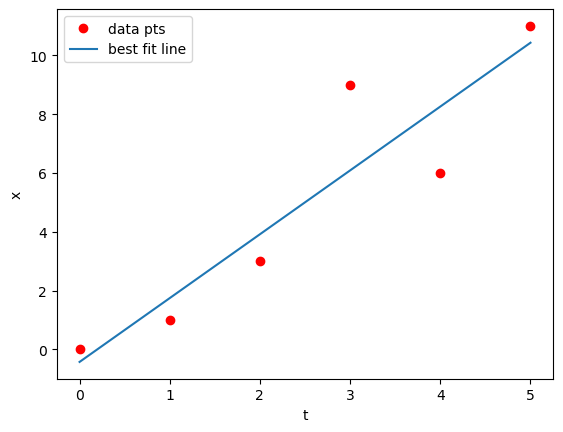

In [7]:
#Question 1: SciPy Curve Fitting
#a) Linear SciPy Fit
def StraightLine(t,a,b):
    return a*t+b

import scipy
import numpy
from matplotlib import pyplot as plot

t_data = numpy.array([0,1,2,3,4,5])
x_data = numpy.array([0,1,3,9,6,11])

parameters, covariance = scipy.optimize.curve_fit(StraightLine, t_data, x_data)

x_continuous=numpy.linspace(0,5,100)
plot.plot(t_data, x_data, 'ro', label='data pts')
plot.xlabel('t')
plot.ylabel('x')
plot.plot(x_continuous, StraightLine(x_continuous,parameters[0],parameters[1]),label='best fit line')
plot.legend()
plot.show()


In [12]:
#b) Gaussian Curve Intro
def gaussian(x,x0,sigma,A):
    return A/(2*numpy.pi*sigma**2)**(1/2)*numpy.exp(-(x-x0)**2/(2*sigma**2))

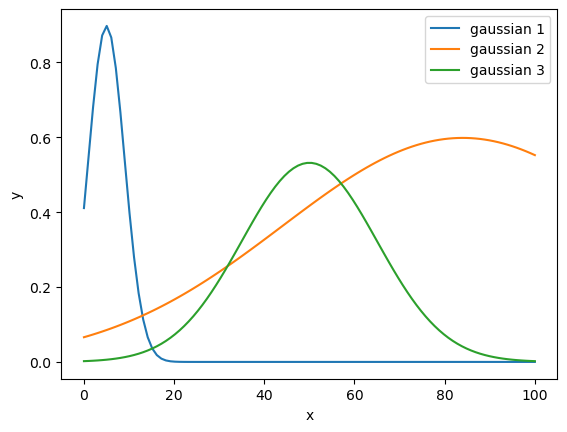

In [25]:
#trials
wideX_continuous=numpy.linspace(0,100,100)

plot.plot(wideX_continuous,gaussian(wideX_continuous,5,4,9),label='gaussian 1')
plot.plot(wideX_continuous,gaussian(wideX_continuous,84,40,60),label='gaussian 2')
plot.plot(wideX_continuous,gaussian(wideX_continuous,50,15,20),label='gaussian 3')
plot.xlabel('x')
plot.ylabel('y')
plot.legend()
plot.show()

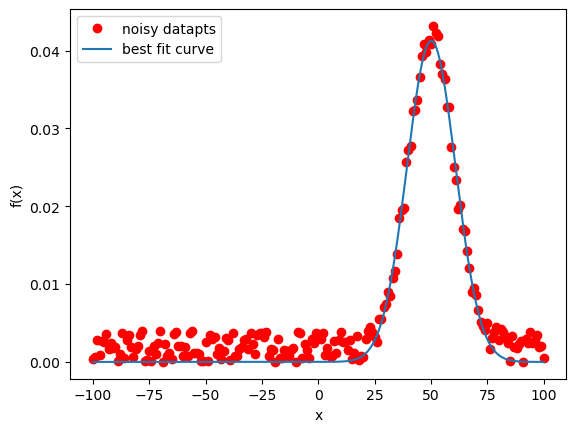

In [32]:
#c) Gaussian SciPy Fit
data=numpy.loadtxt("Gaussian.dat")
x_vals = data[:,0]
f_vals = data[:,1]

coeffs, notUseful = scipy.optimize.curve_fit(gaussian, x_vals, f_vals)
superWideX = numpy.linspace(-100,100,1000)


plot.plot(x_vals,f_vals,'ro',label='noisy datapts')
plot.plot(superWideX,gaussian(superWideX,coeffs[0],coeffs[1],coeffs[2]),label='best fit curve')
plot.xlabel('x')
plot.ylabel('f(x)')
plot.legend()
plot.show()

Question 2: Method of Lines

givens:  
DE: $\frac{\partial^{2}T}{\partial x^{2}}=\frac{\partial T}{\partial t}$  
initial condition: T=1 at t=0  
boundary conditions: T=0 at t=0, x=0 and x=1 
time step=0.1

$T_2=0$ <br> $T_1=1$ <br> $T_0=0$ <br> $T_i=1$ <br> $\Delta t=0.1$ <br> $\Delta x=0.5$

expand DE using finite differences:  
$\frac{T_2-2T_1+T_0}{\Delta x^2} = \frac{T_f-T_i}{\Delta t}$  
solve for final temp:  
$T_f = T_i + \Delta t(\frac{T_2-2T_1+T_0}{\Delta x^2})$

plug and solve:
$T_f = 0.2$

<b><u>Question 3:</b></u>

givens:  
DE: $\alpha\frac{\partial^{2}T}{\partial x^{2}} + \alpha\frac{\partial^{2}T}{\partial y^{2}} + \gamma = 0$  
$\Delta x = 0.5$ <br>
$\Delta y = 0.5$

expanded using finite differences, with nodes labeled 1-9 starting with node one on the bottom left and node 9 on the top right:  
$\alpha \frac{T_4 - 2T_5 + T_6}{\Delta x^2} + \alpha \frac{T_2 - 2T_5 + T_8}{\Delta y^2} + \gamma = 0$

given boundary nodes are all 0, expression simplifies to:  
$\alpha \frac{0 - 2T_5 + 0}{0.25} + \alpha \frac{0 - 2T_5 + 0}{0.25} + \gamma = 0$

Simplifying the terms:  
$-8\alpha T_5 - 8\alpha T_5 + \gamma = 0$  
$-16\alpha T_5 + \gamma = 0$

Solving for the center temperature:  
$T_5 = \frac{\gamma}{16\alpha}$

b) The equation above tells us that the temperature at the internal node is directly proportional to gamma, the heating rate, and inversely proportional to alpha, the thermal conductivity. This means that in order to keep the CPU cool (and thus $T_5$), the heating rate must be reduced or a material with high thermal conductvity must be used. 

c) Lead is the cheapest material, but it has very low thermal conductivity compared to the other materials, serious public health concerns, and is hard to dispose of safely. Gold has very high thermal conductivity, but is too expensive to create a scalable and economically viable product. Aluminum is the best choice because it is comparable in thermal conductivity to gold and comparable in price to lead. It is easily disposable and doesn't cause health concerns. I think all the factors mentioned would be important to consider when picking a material for a similar application, and some of them were considered in this analysis.